# Opis

Notatnik służący do wszelkich wizualizacji wyników itp.

# Importy

In [25]:
IS_NEW_APPROACH = True
IS_VGAE = True

In [26]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys


sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.KlejdaGraphAutoencoder import KlejdaGraphAutoencoder
from src.models.KlejdaGAE.KlejdaVariationalGraphAutoencoder import KlejdaVariationalGraphAutoencoder
from src.models.NewGAE.GraphAutoencoder import GraphAutoencoder
from src.models.NewGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder
import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import os
current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
import frams

frams.init(
    evolution_config['frams_path']
)

Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data



# Histogram rozkładu osobników w zbiorze danych (fitness i parts_num)

In [28]:
genotypes = []
with open("../results/sampled_best_individuals_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)

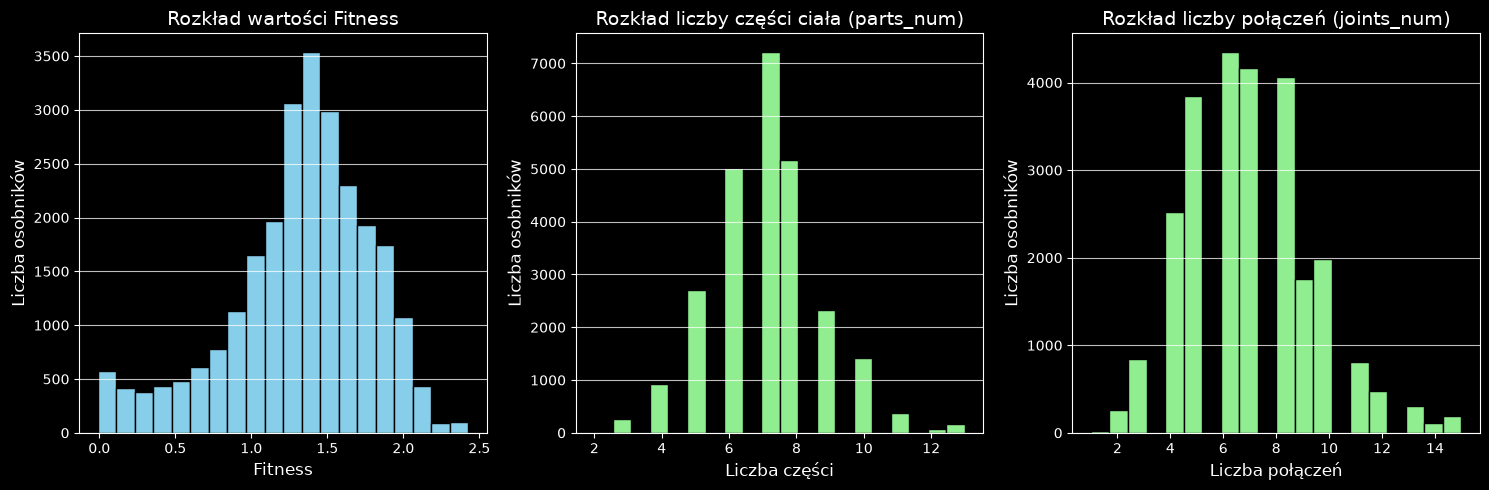

In [30]:
fitness_values = []
parts_nums = []
joints_nums = []

for obj in genotypes:
	# 1. Pobranie wartości fitness (wyciągamy pierwszy element z listy)
	fitness = obj["fitness"][0]
	if fitness < -1:
		continue
	fitness_values.append(fitness)

	# 2. Zliczanie wierszy zaczynających się od 'p:' w genotypie
	genotype_str = obj["genotype"]
	parts_count = sum(1 for line in genotype_str.strip().split('\n') if line.startswith('p:'))
	parts_nums.append(parts_count)
	joints_count = sum(1 for line in genotype_str.strip().split('\n') if line.startswith('j:'))
	joints_nums.append(joints_count)


x_bins = 20 # Liczba kubełków w histogramie

# Tworzymy figurę z dwoma wykresami obok siebie (1 wiersz, 2 kolumny)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# --- Pierwszy wykres: Fitness ---
axes[0].hist(fitness_values, bins=x_bins, color='skyblue', edgecolor='black')
axes[0].set_title('Rozkład wartości Fitness', fontsize=14)
axes[0].set_xlabel('Fitness', fontsize=12)
axes[0].set_ylabel('Liczba osobników', fontsize=12)
axes[0].grid(axis='y', alpha=0.75)

# --- Drugi wykres: Liczba części (parts_num) ---
axes[1].hist(parts_nums, bins=x_bins, color='lightgreen', edgecolor='black')
axes[1].set_title('Rozkład liczby części ciała (parts_num)', fontsize=14)
axes[1].set_xlabel('Liczba części', fontsize=12)
axes[1].set_ylabel('Liczba osobników', fontsize=12)
axes[1].grid(axis='y', alpha=0.75)

# --- Trzeci wykres: Liczba połączeń (joints_num) ---
axes[2].hist(joints_nums, bins=x_bins, color='lightgreen', edgecolor='black')
axes[2].set_title('Rozkład liczby połączeń (joints_num)', fontsize=14)
axes[2].set_xlabel('Liczba połączeń', fontsize=12)
axes[2].set_ylabel('Liczba osobników', fontsize=12)
axes[2].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Wizualizacja przebiegu treningów